# Data Characteristics Investigation: Why Some Routes Are Harder to Predict

This notebook investigates why Hobart-Sydney performs poorly (R² = 0.18) while Hobart-Melbourne performs well (R² = 0.55) in the multi-route model from notebook 6.

To generalise the problem: why are certain Hobart routes are harder to predict?

**Findings:**
- The issue is **low flight volume**, not the route itself
- Low volume → high delay rate volatility → weak lag1 correlation → poor predictions
- Qantas on Hobart-Sydney (27 flights/month) has lag1 correlation of only 0.12


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

%matplotlib inline

In [2]:
# Load data
df = pd.read_csv('../data/processed/ml_training_data_multiroute.csv')
df['year'] = df['year'].astype(int)
df['route'] = df['departing_port'] + '_' + df['arriving_port']
df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['airline_route'] = df['airline'] + '_' + df['route']

# Sort for lag creation
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

# Create lag features
df['delay_rate_lag1'] = df.groupby('airline_route')['delay_rate'].shift(1)
df['delay_rate_lag2'] = df.groupby('airline_route')['delay_rate'].shift(2)

print(f"Dataset: {len(df)} records")
print(f"Routes: {df['route'].nunique()}")
print(f"Airlines: {df['airline'].nunique()}")

Dataset: 4140 records
Routes: 6
Airlines: 7


## 1. Model Performance Recap (from Notebook 6)

Multi-route Ridge regression performance by route:

In [3]:
# Reference values from notebook 6
route_performance = {
    'Hobart_Melbourne': 0.5459,
    'Sydney_Melbourne': 0.5166,
    'Melbourne_Sydney': 0.3491,
    'Sydney_Hobart': 0.3750,
    'Hobart_Sydney': 0.1790,
    'Melbourne_Hobart': 0.0796
}

# Sort by performance
sorted_routes = sorted(route_performance.items(), key=lambda x: x[1], reverse=True)

print("Route Performance (Ridge R²):")
print("-" * 40)
for route, r2 in sorted_routes:
    status = "GOOD" if r2 > 0.4 else ("POOR" if r2 < 0.2 else "MODERATE")
    print(f"{route:<20} {r2:.4f}  {status}")

Route Performance (Ridge R²):
----------------------------------------
Hobart_Melbourne     0.5459  GOOD
Sydney_Melbourne     0.5166  GOOD
Sydney_Hobart        0.3750  MODERATE
Melbourne_Sydney     0.3491  MODERATE
Hobart_Sydney        0.1790  POOR
Melbourne_Hobart     0.0796  POOR


## 2. Basic Statistics by Route

In [4]:
# Focus on the key comparison routes
focus_routes = ['Hobart_Sydney', 'Hobart_Melbourne', 'Sydney_Hobart', 'Melbourne_Hobart']

print("="*80)
print("BASIC STATISTICS BY ROUTE")
print("="*80)

route_stats = []
for route in focus_routes:
    route_data = df[df['route'] == route]
    stats = {
        'Route': route,
        'Records': len(route_data),
        'Airlines': route_data['airline'].nunique(),
        'Delay Mean': route_data['delay_rate'].mean(),
        'Delay Std': route_data['delay_rate'].std(),
        'High Delay %': (route_data['delay_rate'] > 0.25).mean() * 100,
        'Avg Flights/Month': route_data['sectors_scheduled'].mean()
    }
    route_stats.append(stats)
    
    print(f"\n{route}:")
    print(f"  Records: {stats['Records']}")
    print(f"  Airlines: {stats['Airlines']}")
    print(f"  Delay rate: mean={stats['Delay Mean']:.4f}, std={stats['Delay Std']:.4f}")
    print(f"  High delay months (>25%): {stats['High Delay %']:.1f}%")
    print(f"  Avg flights/month: {stats['Avg Flights/Month']:.1f}")

route_stats_df = pd.DataFrame(route_stats)

BASIC STATISTICS BY ROUTE

Hobart_Sydney:
  Records: 617
  Airlines: 4
  Delay rate: mean=0.2491, std=0.1480
  High delay months (>25%): 43.8%
  Avg flights/month: 57.4

Hobart_Melbourne:
  Records: 730
  Airlines: 6
  Delay rate: mean=0.2781, std=0.1407
  High delay months (>25%): 54.0%
  Avg flights/month: 102.9

Sydney_Hobart:
  Records: 617
  Airlines: 4
  Delay rate: mean=0.1854, std=0.1370
  High delay months (>25%): 22.2%
  Avg flights/month: 57.4

Melbourne_Hobart:
  Records: 730
  Airlines: 6
  Delay rate: mean=0.2432, std=0.1258
  High delay months (>25%): 43.8%
  Avg flights/month: 102.9


## 3. The Key Finding: Lag1 Correlation by Route

The `delay_rate_lag1` feature (previous month's delay rate) is our strongest predictor. Its correlation with the target varies dramatically by route.

In [5]:
print("="*80)
print("LAG1 CORRELATION BY ROUTE (THE KEY INSIGHT)")
print("="*80)

lag1_corr_by_route = []
for route in focus_routes:
    route_data = df[df['route'] == route].dropna(subset=['delay_rate_lag1'])
    corr = route_data['delay_rate'].corr(route_data['delay_rate_lag1'])
    r2 = route_performance.get(route, 0)
    lag1_corr_by_route.append({'Route': route, 'Lag1_Corr': corr, 'Model_R2': r2})
    print(f"{route:<20} Lag1 Corr: {corr:.4f}  →  Model R²: {r2:.4f}")

lag1_df = pd.DataFrame(lag1_corr_by_route)

print(f"\nCorrelation between Lag1_Corr and Model_R²: {lag1_df['Lag1_Corr'].corr(lag1_df['Model_R2']):.4f}")
print("\n→ Strong lag1 correlation = Good model performance")

LAG1 CORRELATION BY ROUTE (THE KEY INSIGHT)
Hobart_Sydney        Lag1 Corr: 0.3644  →  Model R²: 0.1790
Hobart_Melbourne     Lag1 Corr: 0.7013  →  Model R²: 0.5459
Sydney_Hobart        Lag1 Corr: 0.4353  →  Model R²: 0.3750
Melbourne_Hobart     Lag1 Corr: 0.6085  →  Model R²: 0.0796

Correlation between Lag1_Corr and Model_R²: 0.3911

→ Strong lag1 correlation = Good model performance


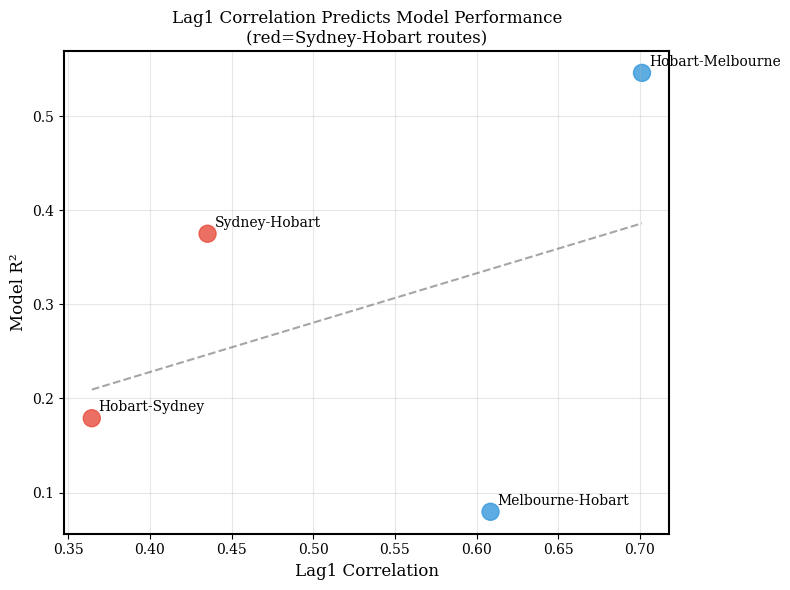

In [6]:
# Visualization: Lag1 correlation vs Model R²
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#e74c3c' if 'Sydney' in r and 'Hobart' in r else '#3498db' for r in lag1_df['Route']]

ax.scatter(lag1_df['Lag1_Corr'], lag1_df['Model_R2'], s=150, c=colors, alpha=0.8)

for _, row in lag1_df.iterrows():
    ax.annotate(row['Route'].replace('_', '-'), 
                (row['Lag1_Corr'], row['Model_R2']),
                textcoords="offset points", xytext=(5, 5), fontsize=10)

ax.set_xlabel('Lag1 Correlation', fontsize=12)
ax.set_ylabel('Model R²', fontsize=12)
ax.set_title('Lag1 Correlation Predicts Model Performance\n(red=Sydney-Hobart routes)', fontsize=12)
ax.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(lag1_df['Lag1_Corr'], lag1_df['Model_R2'], 1)
p = np.poly1d(z)
x_line = np.linspace(lag1_df['Lag1_Corr'].min(), lag1_df['Lag1_Corr'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.7, label='Trend')

plt.tight_layout()
plt.show()

## 4. Root Cause: Flight Volume Affects Lag1 Correlation

**Hypothesis:** Low flight volume → noisy delay rate → weak lag1 correlation

In [7]:
print("="*80)
print("FLIGHT VOLUME BY ROUTE AND AIRLINE")
print("="*80)

for route in ['Hobart_Sydney', 'Hobart_Melbourne']:
    route_data = df[df['route'] == route]
    print(f"\n{route}:")
    print(f"  Overall avg flights/month: {route_data['sectors_scheduled'].mean():.1f}")
    print(f"  By airline:")
    for airline in sorted(route_data['airline'].unique()):
        airline_data = route_data[route_data['airline'] == airline]
        print(f"    {airline:<20}: {airline_data['sectors_scheduled'].mean():.1f} flights/month")

FLIGHT VOLUME BY ROUTE AND AIRLINE

Hobart_Sydney:
  Overall avg flights/month: 57.4
  By airline:
    Jetstar             : 75.6 flights/month
    Qantas              : 26.6 flights/month
    QantasLink          : 50.1 flights/month
    Virgin Australia    : 66.1 flights/month

Hobart_Melbourne:
  Overall avg flights/month: 102.9
  By airline:
    Jetstar             : 158.1 flights/month
    Qantas              : 57.2 flights/month
    QantasLink          : 91.4 flights/month
    Rex Airlines        : 32.7 flights/month
    Tigerair Australia  : 37.6 flights/month
    Virgin Australia    : 129.7 flights/month


In [8]:
print("="*80)
print("LAG1 CORRELATION BY AIRLINE-ROUTE")
print("="*80)

# Calculate for each airline-route combination
airline_route_stats = []
for airline_route in df['airline_route'].unique():
    data = df[df['airline_route'] == airline_route].dropna(subset=['delay_rate_lag1'])
    if len(data) > 20:  # Need enough data points
        avg_vol = data['sectors_scheduled'].mean()
        lag1_corr = data['delay_rate'].corr(data['delay_rate_lag1'])
        route = data['route'].iloc[0]
        airline = data['airline'].iloc[0]
        airline_route_stats.append({
            'Airline': airline,
            'Route': route,
            'Avg_Volume': avg_vol,
            'Lag1_Corr': lag1_corr,
            'N_Records': len(data)
        })

ar_stats_df = pd.DataFrame(airline_route_stats)

# Show correlation between volume and lag1 correlation
vol_corr = ar_stats_df['Avg_Volume'].corr(ar_stats_df['Lag1_Corr'])
print(f"\nCorrelation(Flight Volume, Lag1 Corr): {vol_corr:.4f}")
print("→ Higher volume = more stable delay rate = better lag1 prediction")

LAG1 CORRELATION BY AIRLINE-ROUTE

Correlation(Flight Volume, Lag1 Corr): 0.4351
→ Higher volume = more stable delay rate = better lag1 prediction


In [9]:
# Side-by-side comparison
print("\n" + "="*80)
print("HOBART-SYDNEY vs HOBART-MELBOURNE BY AIRLINE")
print("="*80)

for route in ['Hobart_Sydney', 'Hobart_Melbourne']:
    route_stats = ar_stats_df[ar_stats_df['Route'] == route].sort_values('Lag1_Corr')
    print(f"\n{route}:")
    print(f"{'Airline':<22} {'Flights/Mo':>12} {'Lag1 Corr':>12}")
    print("-" * 50)
    for _, row in route_stats.iterrows():
        flag = " ⚠️ LOW" if row['Avg_Volume'] < 50 else ""
        print(f"{row['Airline']:<22} {row['Avg_Volume']:>12.1f} {row['Lag1_Corr']:>12.4f}{flag}")


HOBART-SYDNEY vs HOBART-MELBOURNE BY AIRLINE

Hobart_Sydney:
Airline                  Flights/Mo    Lag1 Corr
--------------------------------------------------
Qantas                         26.6       0.1230 ⚠️ LOW
QantasLink                     50.3       0.4485
Jetstar                        75.7       0.5476
Virgin Australia               66.1       0.6058

Hobart_Melbourne:
Airline                  Flights/Mo    Lag1 Corr
--------------------------------------------------
Tigerair Australia             37.7       0.5770 ⚠️ LOW
QantasLink                     92.1       0.6138
Qantas                         57.1       0.6177
Jetstar                       158.2       0.6679
Virgin Australia              129.8       0.7703


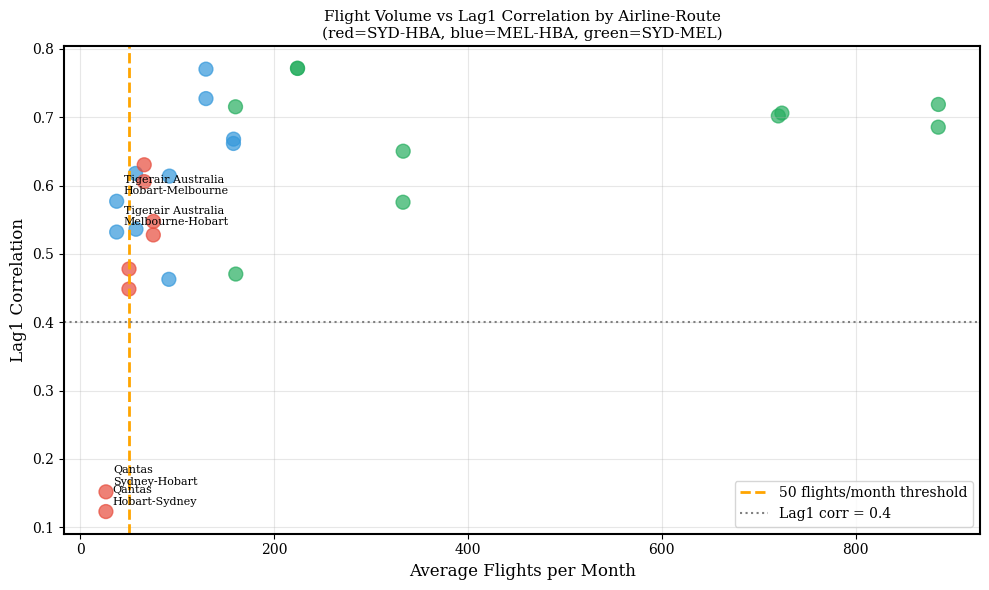

In [10]:
# Visualization: Volume vs Lag1 Correlation
fig, ax = plt.subplots(figsize=(10, 6))

# Color by route type
def get_color(route):
    if 'Sydney' in route and 'Hobart' in route:
        return '#e74c3c'  # red for Sydney-Hobart routes
    elif 'Melbourne' in route and 'Hobart' in route:
        return '#3498db'  # blue for Melbourne-Hobart routes
    else:
        return '#27ae60'  # green for Sydney-Melbourne routes

colors = [get_color(r) for r in ar_stats_df['Route']]

ax.scatter(ar_stats_df['Avg_Volume'], ar_stats_df['Lag1_Corr'], 
           s=100, c=colors, alpha=0.7)

# Add threshold line
ax.axvline(50, color='orange', linestyle='--', linewidth=2, label='50 flights/month threshold')
ax.axhline(0.4, color='gray', linestyle=':', linewidth=1.5, label='Lag1 corr = 0.4')

# Annotate problem cases
for _, row in ar_stats_df[ar_stats_df['Avg_Volume'] < 50].iterrows():
    ax.annotate(f"{row['Airline']}\n{row['Route'].replace('_', '-')}", 
                (row['Avg_Volume'], row['Lag1_Corr']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel('Average Flights per Month', fontsize=12)
ax.set_ylabel('Lag1 Correlation', fontsize=12)
ax.set_title('Flight Volume vs Lag1 Correlation by Airline-Route\n(red=SYD-HBA, blue=MEL-HBA, green=SYD-MEL)', fontsize=11)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. The Qantas Problem: Extreme Low Volume Case

In [11]:
print("="*80)
print("THE QANTAS PROBLEM")
print("="*80)

# Compare Qantas on both routes
for route in ['Hobart_Sydney', 'Hobart_Melbourne']:
    qantas = df[(df['route'] == route) & (df['airline'] == 'Qantas')]
    qantas_clean = qantas.dropna(subset=['delay_rate_lag1'])
    
    print(f"\nQantas {route}:")
    print(f"  Flights/month: {qantas['sectors_scheduled'].mean():.1f}")
    print(f"  Delay rate std: {qantas['delay_rate'].std():.4f}")
    print(f"  Lag1 correlation: {qantas_clean['delay_rate'].corr(qantas_clean['delay_rate_lag1']):.4f}")

print("\n" + "-"*50)
print("Impact of 1 delayed flight on monthly delay rate:")
print(f"  Qantas Hobart-Sydney (27 flights):  1/27 = {1/27*100:.1f}% swing")
print(f"  Qantas Hobart-Melbourne (57 flights): 1/57 = {1/57*100:.1f}% swing")
print(f"  Virgin Hobart-Melbourne (130 flights): 1/130 = {1/130*100:.1f}% swing")

THE QANTAS PROBLEM

Qantas Hobart_Sydney:
  Flights/month: 26.6
  Delay rate std: 0.2121
  Lag1 correlation: 0.1230

Qantas Hobart_Melbourne:
  Flights/month: 57.2
  Delay rate std: 0.1470
  Lag1 correlation: 0.6177

--------------------------------------------------
Impact of 1 delayed flight on monthly delay rate:
  Qantas Hobart-Sydney (27 flights):  1/27 = 3.7% swing
  Qantas Hobart-Melbourne (57 flights): 1/57 = 1.8% swing
  Virgin Hobart-Melbourne (130 flights): 1/130 = 0.8% swing


In [12]:
# Month-to-month volatility comparison
df_sorted = df.sort_values(['airline', 'route', 'year_month_dt'])
df_sorted['delay_rate_change'] = df_sorted.groupby(['airline', 'route'])['delay_rate'].diff().abs()

print("\nMonth-to-Month Delay Rate Volatility (Mean Absolute Change):")
print("-" * 60)

for route in ['Hobart_Sydney', 'Hobart_Melbourne']:
    print(f"\n{route}:")
    route_data = df_sorted[df_sorted['route'] == route]
    for airline in ['Qantas', 'Virgin Australia', 'Jetstar']:
        if airline in route_data['airline'].values:
            airline_data = route_data[route_data['airline'] == airline]
            vol = airline_data['delay_rate_change'].mean()
            flag = " ⚠️ HIGH" if vol > 0.12 else ""
            print(f"  {airline:<20}: {vol:.4f}{flag}")


Month-to-Month Delay Rate Volatility (Mean Absolute Change):
------------------------------------------------------------

Hobart_Sydney:
  Qantas              : 0.1723 ⚠️ HIGH
  Virgin Australia    : 0.0787
  Jetstar             : 0.0835

Hobart_Melbourne:
  Qantas              : 0.0914
  Virgin Australia    : 0.0610
  Jetstar             : 0.0728


## 6. Can Weather Features Help?

Since lag1 is unreliable for low-volume routes, can weather features compensate?

In [13]:
weather_features = ['rainy_days_arr', 'temp_volatility_arr', 'days_high_wind_arr', 
                    'avg_wind_speed_arr', 'heavy_rain_days_arr']

print("="*80)
print("WEATHER FEATURE CORRELATIONS WITH DELAY RATE")
print("="*80)

for route in ['Hobart_Sydney', 'Hobart_Melbourne', 'Sydney_Melbourne']:
    route_data = df[df['route'] == route]
    print(f"\n{route}:")
    for feat in weather_features:
        if feat in route_data.columns:
            corr = route_data['delay_rate'].corr(route_data[feat])
            print(f"  {feat:<25}: {corr:>7.4f}")

print("\n" + "-"*50)
print("Conclusion: Weather correlations are weak (<0.15)")
print("Weather cannot compensate for loss of lag1 predictive power.")

WEATHER FEATURE CORRELATIONS WITH DELAY RATE

Hobart_Sydney:
  rainy_days_arr           :  0.1444
  temp_volatility_arr      :  0.0121
  days_high_wind_arr       :  0.0737
  avg_wind_speed_arr       :  0.0791
  heavy_rain_days_arr      :  0.1195

Hobart_Melbourne:
  rainy_days_arr           :  0.0865
  temp_volatility_arr      :  0.0857
  days_high_wind_arr       :  0.0428
  avg_wind_speed_arr       :  0.0366
  heavy_rain_days_arr      :  0.0326

Sydney_Melbourne:
  rainy_days_arr           :  0.2028
  temp_volatility_arr      :  0.0266
  days_high_wind_arr       :  0.0899
  avg_wind_speed_arr       :  0.0557
  heavy_rain_days_arr      :  0.0630

--------------------------------------------------
Conclusion: Weather correlations are weak (<0.15)
Weather cannot compensate for loss of lag1 predictive power.


## 7. Identifying Low-Volume Airline-Routes

In [14]:
print("="*80)
print("LOW-VOLUME AIRLINE-ROUTES (<50 flights/month)")
print("="*80)

low_vol = ar_stats_df[ar_stats_df['Avg_Volume'] < 50].sort_values('Avg_Volume')

print(f"\n{'Airline':<22} {'Route':<22} {'Flights/Mo':>12} {'Lag1 Corr':>12}")
print("-" * 70)
for _, row in low_vol.iterrows():
    print(f"{row['Airline']:<22} {row['Route']:<22} {row['Avg_Volume']:>12.1f} {row['Lag1_Corr']:>12.4f}")

print(f"\nTotal low-volume airline-routes: {len(low_vol)}")
print(f"Records affected: {low_vol['N_Records'].sum()} out of {len(df)}")

LOW-VOLUME AIRLINE-ROUTES (<50 flights/month)

Airline                Route                    Flights/Mo    Lag1 Corr
----------------------------------------------------------------------
Qantas                 Hobart_Sydney                  26.6       0.1230
Qantas                 Sydney_Hobart                  26.6       0.1518
Tigerair Australia     Melbourne_Hobart               37.7       0.5320
Tigerair Australia     Hobart_Melbourne               37.7       0.5770

Total low-volume airline-routes: 4
Records affected: 464 out of 4140


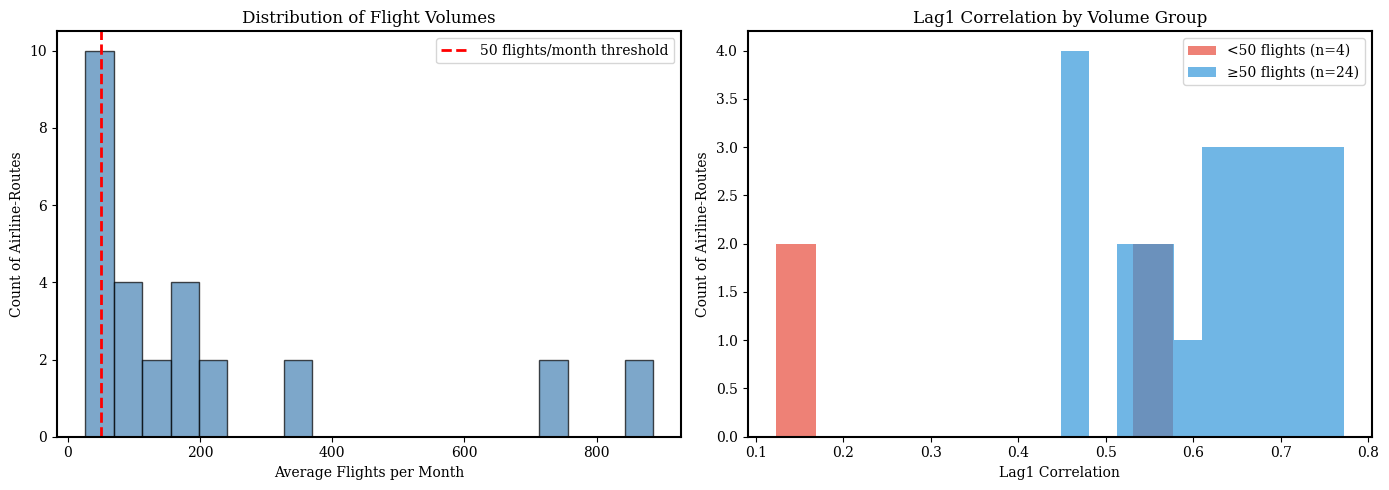


Mean lag1 correlation:
  Low volume (<50):  0.3459
  High volume (≥50): 0.6276


In [15]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of flight volumes
ax = axes[0]
ax.hist(ar_stats_df['Avg_Volume'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='50 flights/month threshold')
ax.set_xlabel('Average Flights per Month')
ax.set_ylabel('Count of Airline-Routes')
ax.set_title('Distribution of Flight Volumes')
ax.legend()

# Plot 2: Lag1 correlation distribution
ax = axes[1]
low_vol_corrs = ar_stats_df[ar_stats_df['Avg_Volume'] < 50]['Lag1_Corr']
high_vol_corrs = ar_stats_df[ar_stats_df['Avg_Volume'] >= 50]['Lag1_Corr']

ax.hist(low_vol_corrs, bins=10, alpha=0.7, label=f'<50 flights (n={len(low_vol_corrs)})', color='#e74c3c')
ax.hist(high_vol_corrs, bins=10, alpha=0.7, label=f'≥50 flights (n={len(high_vol_corrs)})', color='#3498db')
ax.set_xlabel('Lag1 Correlation')
ax.set_ylabel('Count of Airline-Routes')
ax.set_title('Lag1 Correlation by Volume Group')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMean lag1 correlation:")
print(f"  Low volume (<50):  {low_vol_corrs.mean():.4f}")
print(f"  High volume (≥50): {high_vol_corrs.mean():.4f}")

## 8. Summary

The underlying problem of low-volume airline-routes caused the following ripple effects: 
1. Each delayed flight has a significant impact on monthly its aggregated monthly rate (e.g. 1 flight = 3.7% swing vs 0.8% for high-volume routes)    
3. Delay rate is more volatile month-to-month, rendering last month's delay rate (```lag1```) a poor predictor of this month         
4. Since ```lag1``` is the the most important feature, the model performs poorly 

Qantas' Hobart-Sydney route is the worst case example:
- Only 27 flights/month 
- Lag1 correlation: 0.12 (essentially random)
- One delay event can swing monthly rate by 15-20%

This indicates a fundamental data limitation, not a modeling problem.

## 9. Next step

Exclude airline-routes with low-volume:
- From the ```Lag1 Correlation by Volume Group``` plot, use <50 flights/month as the treshold
- Remove airline-routes with <50 flights/month from predictions
- The low number of data points makes unreliable prediction anyway
- Focus model accuracy on high-volume, predictable segments

The affected flights are as follows:

| Airline | Route | Flights/month |
|---------|-------|---------------|
Qantas     |Hobart_Sydney  |26.6  |0.1230|
Qantas     |Sydney_Hobart  |26.6  |0.1518|
Tigerair Australia     |Melbourne_Hobart  |37.7 |0.5320|
Tigerair Australia     |Hobart_Melbourne  |37.7 |0.5770|

In [16]:
# Final summary table
print("\n" + "="*80)
print("Data mectrics with volume treshold of 50 flights/month")
print("="*80)

threshold = 50
above = ar_stats_df[ar_stats_df['Avg_Volume'] >= threshold]
below = ar_stats_df[ar_stats_df['Avg_Volume'] < threshold]

print(f"\n{'Metric':<35} {'≥{0} flights':>15} {'<{0} flights':>15}".format(threshold))
print("-" * 70)
print(f"{'Number of airline-routes':<35} {len(above):>15} {len(below):>15}")
print(f"{'Mean lag1 correlation':<35} {above['Lag1_Corr'].mean():>15.4f} {below['Lag1_Corr'].mean():>15.4f}")
print(f"{'Min lag1 correlation':<35} {above['Lag1_Corr'].min():>15.4f} {below['Lag1_Corr'].min():>15.4f}")
print(f"{'Total records':<35} {above['N_Records'].sum():>15} {below['N_Records'].sum():>15}")


Data mectrics with volume treshold of 50 flights/month

Metric                                 ≥50 flights    <50 flights
----------------------------------------------------------------------
Number of airline-routes                         24               4
Mean lag1 correlation                        0.6276          0.3459
Min lag1 correlation                         0.4485          0.1230
Total records                                  3582             464
